# Modello per l'Identificazione della Lingua di Testi per un Museo </p> Caso d'Uso Aziendale: MuseumLangID

## Introduzione all'Azienda
MuseumLangID è un'iniziativa di un museo internazionale che ospita una vasta collezione di opere d'arte e manufatti. Le descrizioni degli oggetti sono spesso scritte in diverse lingue, e il personale del museo ha bisogno di uno strumento automatizzato per identificare rapidamente la lingua di questi testi.

## Problema
La gestione delle informazioni multilingue è una sfida significativa per il museo. Attualmente, la lingua di ogni descrizione deve essere identificata manualmente, il che richiede tempo e può portare a errori. Con l'espansione delle collezioni, il numero di testi da analizzare aumenta, rendendo necessario un approccio automatizzato e scalabile.

## Obiettivo del Progetto
L'obiettivo è sviluppare un modello di machine learning basato su tecniche di Natural Language Processing (NLP) per identificare la lingua di testi forniti dal museo. Questo modello dovrà:
1. Riconoscere automaticamente la lingua di un testo.
2. Supportare almeno 3 lingue principali.
3. Essere facile da integrare con il sistema esistente del museo.

## Benefici Attesi
- Automazione: Eliminare la necessità di identificazione manuale delle lingue.
- Efficienza: Processare rapidamente grandi volumi di testi.
- Accuratezza: Ridurre gli errori umani nell'identificazione delle lingue.

## Specifiche del Progetto
### Dataset
Il dataset è disponibile a questo link: https://raw.githubusercontent.com/Profession-AI/progetti-ml/refs/heads/main/Modello%20per%20l'identificazione%20della%20lingua%20dei%20testi%20di%20un%20museo/museo_descrizioni.csv. Contiene varie descrizioni in più lingue, con una colonna che rappresenta il codice della lingua, che è il target da prevedere.

### Tecnologie
- Linguaggio di programmazione: Python
- Librerie richieste:
    - scikit-learn
    - nltk
    - numpy
    - pandas

### Funzionalità Chiave
1. Preprocessing dei Dati:
    - Pulizia del testo (rimozione di caratteri speciali, normalizzazione).
    - Tokenizzazione e rappresentazione dei testi in un formato numerico (ad esempio, Bag of Words o TF-IDF).
2. Sviluppo del Modello:
    - Creazione di un modello di classificazione delle lingue basato su algoritmi di machine learning (ad esempio, Naive Bayes, Support Vector Machine o Random Forest).
    - Addestramento e validazione del modello sul dataset fornito.
3. Valutazione:
    - Utilizzare metriche come accuratezza, precisione, richiamo e F1-score per valutare le prestazioni del modello.

## Consegna
Dovrai consegnare un notebook che riporta la creazione del modello, i vari test per validare le sue performance e anche un commento a tali risultati.

## Import delle Librerie e hyperparametri

In [17]:
import pandas as pd
import spacy
import re
import matplotlib.pyplot as plt
import string
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [29]:
RANDOM_SEED = 42
TEST_SPLIT_SIZE = 0.2

# TF-IDF Hyperparameters
TFIDF_MAX_FEATURES = 1000  # Limite numero massimo di feature
TFIDF_NGRAM_RANGE = (1, 2) # Considera unigrammi e bigrammi
TFIDF_MIN_DF = 0.005 # Ignora parole che appaiono in meno del 20% dei documenti
TFIDF_MAX_DF = 0.8 # Ignora parole che appaiono in più dell'80% dei documenti (stop words)

## 1. Dataset

In [19]:
dataset = pd.read_csv('https://raw.githubusercontent.com/Profession-AI/progetti-ml/refs/heads/main/Modello%20per%20l%27identificazione%20della%20lingua%20dei%20testi%20di%20un%20museo/museo_descrizioni.csv')

dataset_testo = dataset.iloc[:, 0]  # Testo
dataset_lingua = dataset.iloc[:, -1]  # Codice Lingua (target)

# 3 righe per ogni classe
dataset.groupby(dataset.columns[-1]).head(3)

,Testo,Codice Lingua
0,Statua in marmo di un imperatore romano del II...,it
1,Anfora greca con decorazioni a figure nere,it
2,Dipinto rinascimentale raffigurante la Madonna...,it
98,Marble statue of a Roman emperor from the 2nd ...,en
99,Greek amphora with black-figure decorations,en
100,Renaissance painting depicting the Madonna and...,en
196,Marmorstatue eines römischen Kaisers aus dem 2...,de
197,Griechische Amphore mit schwarzfigurigen Verzi...,de
198,Renaissance-Gemälde der Madonna mit Kind,de


In [20]:
print("=" * 50)
print(" CARATTERISTICHE DEL DATASET")
print("=" * 50)
print(f"  Righe    : {dataset.shape[0]}")
print(f"  Colonne  : {dataset.shape[1]}")
print(f"  Features  : {dataset.columns.tolist()}")
print(f"  Lingue presenti: {dataset_lingua.nunique()}")
for lang, count in dataset_lingua.value_counts().items():
    print(f"    - {lang}: {count} campioni ({(count/dataset.shape[0])*100:.2f}%)")

 CARATTERISTICHE DEL DATASET
  Righe    : 294
  Colonne  : 2
  Features  : ['Testo', 'Codice Lingua']
  Lingue presenti: 3
    - it: 98 campioni (33.33%)
    - en: 98 campioni (33.33%)
    - de: 98 campioni (33.33%)


Il dataset é perfettamente bilanciato, con un numero uguale di campioni per ogni lingua.
Non sono presenti valori mancanti

## 2. Preprocessing dei Dati

Visto che il task é una language identification, i numeri si possono rimuovere del tutto. Le stopwords invece provo a lasciarle, visto che possono essere molto indicative della lingua (ad esempio "the" per l'inglese, "le" per il francese)

In [32]:
# Lemmatizazione

!python -m spacy download it_core_news_sm
!python -m spacy download en_core_web_sm
!python -m spacy download de_core_news_sm

nlp_ita = spacy.load('it_core_news_sm')
nlp_en = spacy.load('en_core_web_sm')
nlp_de = spacy.load('de_core_news_sm')

# Mappa dei modelli spaCy per lingua (codici ISO 639-1)
nlp_map = {
    'it': nlp_ita,
    'en': nlp_en,
    'de': nlp_de,
}

def data_cleaner(dataset_testo, dataset_lingua):
    """
    Pulisce e lemmatizza i testi usando il modello spaCy corretto per ogni lingua.
    Per lingue non supportate esplicitamente, viene effettuata solo la pulizia base.
    """
    dataset_to_return = []
    for sentence, lang in zip(dataset_testo, dataset_lingua):
        sentence = sentence.lower()
        for c in string.punctuation:
            sentence = sentence.replace(c, " ")
        nlp = nlp_map.get(lang)
        if nlp is not None:
            document = nlp(sentence)
            sentence = ' '.join(token.lemma_ for token in document)
        sentence = re.sub(r'\d+', '', sentence)
        sentence = re.sub(r'\s+', ' ', sentence).strip()
        dataset_to_return.append(sentence)
    return dataset_to_return

     ---------------------------------------- 0.0/13.0 MB ? eta -:--:--
     ---------------------------------------- 13.0/13.0 MB 165.3 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('it_core_news_sm')
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     -------------------------- ------------- 8.4/12.8 MB 43.1 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 51.8 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
     ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
     ---------------------- ----------------- 8.1/14.6 MB 42.5 MB/s eta 0:00:01
     ---------------------------------------- 14.6/14.6 MB 56.4 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')


In [30]:
# Pulizia del dataset
dataset_cleaned = data_cleaner(dataset_testo, dataset_lingua)

# Split del dataset
X_train, X_test, y_train, y_test = train_test_split(dataset_cleaned, dataset_lingua, test_size=TEST_SPLIT_SIZE, random_state=RANDOM_SEED, stratify=dataset_lingua)

# Feature extraction con TF-IDF
vectorizer = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES, ngram_range=TFIDF_NGRAM_RANGE, min_df=TFIDF_MIN_DF, max_df=TFIDF_MAX_DF)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("=" * 50)
print(" PREPROCESSING E SPLIT DEL DATASET")
print("=" * 50)
print(f"  Training set : {len(X_train)} campioni ({(1 - TEST_SPLIT_SIZE) * 100:.0f}%)")
print(f"  Test set     : {len(X_test)} campioni ({TEST_SPLIT_SIZE * 100:.0f}%)")
print()
print("  Distribuzione nel Training set:")
for lang, count in y_train.value_counts().items():
    print(f"    - {lang}: {count} campioni ({(count / len(y_train)) * 100:.2f}%)")
print()
print("  Distribuzione nel Test set:")
for lang, count in y_test.value_counts().items():
    print(f"    - {lang}: {count} campioni ({(count / len(y_test)) * 100:.2f}%)")
print()
print("  Forma della matrice TF-IDF del training set: ", X_train_tfidf.shape)
print("  Forma della matrice TF-IDF del test set: ", X_test_tfidf.shape)


 PREPROCESSING E SPLIT DEL DATASET
  Training set : 235 campioni (80%)
  Test set     : 59 campioni (20%)

  Distribuzione nel Training set:
    - de: 79 campioni (33.62%)
    - en: 78 campioni (33.19%)
    - it: 78 campioni (33.19%)

  Distribuzione nel Test set:
    - it: 20 campioni (33.90%)
    - en: 20 campioni (33.90%)
    - de: 19 campioni (32.20%)

  Forma della matrice TF-IDF del training set:  (235, 304)
  Forma della matrice TF-IDF del test set:  (59, 304)


## 3. Sviluppo e Addestramento dei Modelli

In [8]:
### Modello 1: Naive Bayes Multinomiale
print("="*60)
print("MODELLO 1: NAIVE BAYES MULTINOMIALE")
print("="*60)

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Predizioni
y_pred_nb = nb_model.predict(X_test_tfidf)

# Accuratezza
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"\nAccuratezza: {accuracy_nb:.4f}")
print(f"\nReport di classificazione:\n{classification_report(y_test, y_pred_nb)}")

MODELLO 1: NAIVE BAYES MULTINOMIALE

Accuratezza: 0.9831

Report di classificazione:
              precision    recall  f1-score   support

          de       1.00      1.00      1.00        19
          en       1.00      0.95      0.97        20
          it       0.95      1.00      0.98        20

    accuracy                           0.98        59
   macro avg       0.98      0.98      0.98        59
weighted avg       0.98      0.98      0.98        59



In [9]:
### Modello 2: Support Vector Machine (SVM)
print("\n" + "="*60)
print("MODELLO 2: SUPPORT VECTOR MACHINE (LinearSVC)")
print("="*60)

svm_model = LinearSVC(random_state=RANDOM_SEED, max_iter=1000)
svm_model.fit(X_train_tfidf, y_train)

# Predizioni
y_pred_svm = svm_model.predict(X_test_tfidf)

# Accuratezza
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"\nAccuratezza: {accuracy_svm:.4f}")
print(f"\nReport di classificazione:\n{classification_report(y_test, y_pred_svm)}")


MODELLO 2: SUPPORT VECTOR MACHINE (LinearSVC)

Accuratezza: 0.9831

Report di classificazione:
              precision    recall  f1-score   support

          de       1.00      1.00      1.00        19
          en       1.00      0.95      0.97        20
          it       0.95      1.00      0.98        20

    accuracy                           0.98        59
   macro avg       0.98      0.98      0.98        59
weighted avg       0.98      0.98      0.98        59



In [10]:
### Modello 3: Random Forest
print("\n" + "="*60)
print("MODELLO 3: RANDOM FOREST")
print("="*60)

rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)

# Predizioni
y_pred_rf = rf_model.predict(X_test_tfidf)

# Accuratezza
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nAccuratezza: {accuracy_rf:.4f}")
print(f"\nReport di classificazione:\n{classification_report(y_test, y_pred_rf)}")


MODELLO 3: RANDOM FOREST

Accuratezza: 0.9661

Report di classificazione:
              precision    recall  f1-score   support

          de       0.90      1.00      0.95        19
          en       1.00      0.90      0.95        20
          it       1.00      1.00      1.00        20

    accuracy                           0.97        59
   macro avg       0.97      0.97      0.97        59
weighted avg       0.97      0.97      0.97        59



## 4. Valutazione Comparativa dei Modelli

In [11]:
# Creazione di un DataFrame di comparazione delle metriche
results = []

# Naive Bayes
results.append({
    'Modello': 'Naive Bayes',
    'Accuratezza': accuracy_score(y_test, y_pred_nb),
    'Precisione': precision_score(y_test, y_pred_nb, average='weighted'),
    'Richiamo': recall_score(y_test, y_pred_nb, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_nb, average='weighted')
})

# SVM
results.append({
    'Modello': 'SVM (LinearSVC)',
    'Accuratezza': accuracy_score(y_test, y_pred_svm),
    'Precisione': precision_score(y_test, y_pred_svm, average='weighted'),
    'Richiamo': recall_score(y_test, y_pred_svm, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_svm, average='weighted')
})

# Random Forest
results.append({
    'Modello': 'Random Forest',
    'Accuratezza': accuracy_score(y_test, y_pred_rf),
    'Precisione': precision_score(y_test, y_pred_rf, average='weighted'),
    'Richiamo': recall_score(y_test, y_pred_rf, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_rf, average='weighted')
})

comparison_df = pd.DataFrame(results)
print("\n" + "="*80)
print("TABELLA COMPARATIVA DELLE METRICHE")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


TABELLA COMPARATIVA DELLE METRICHE
        Modello  Accuratezza  Precisione  Richiamo  F1-Score
    Naive Bayes     0.983051    0.983858  0.983051  0.983040
SVM (LinearSVC)     0.983051    0.983858  0.983051  0.983040
  Random Forest     0.966102    0.969330  0.966102  0.966057


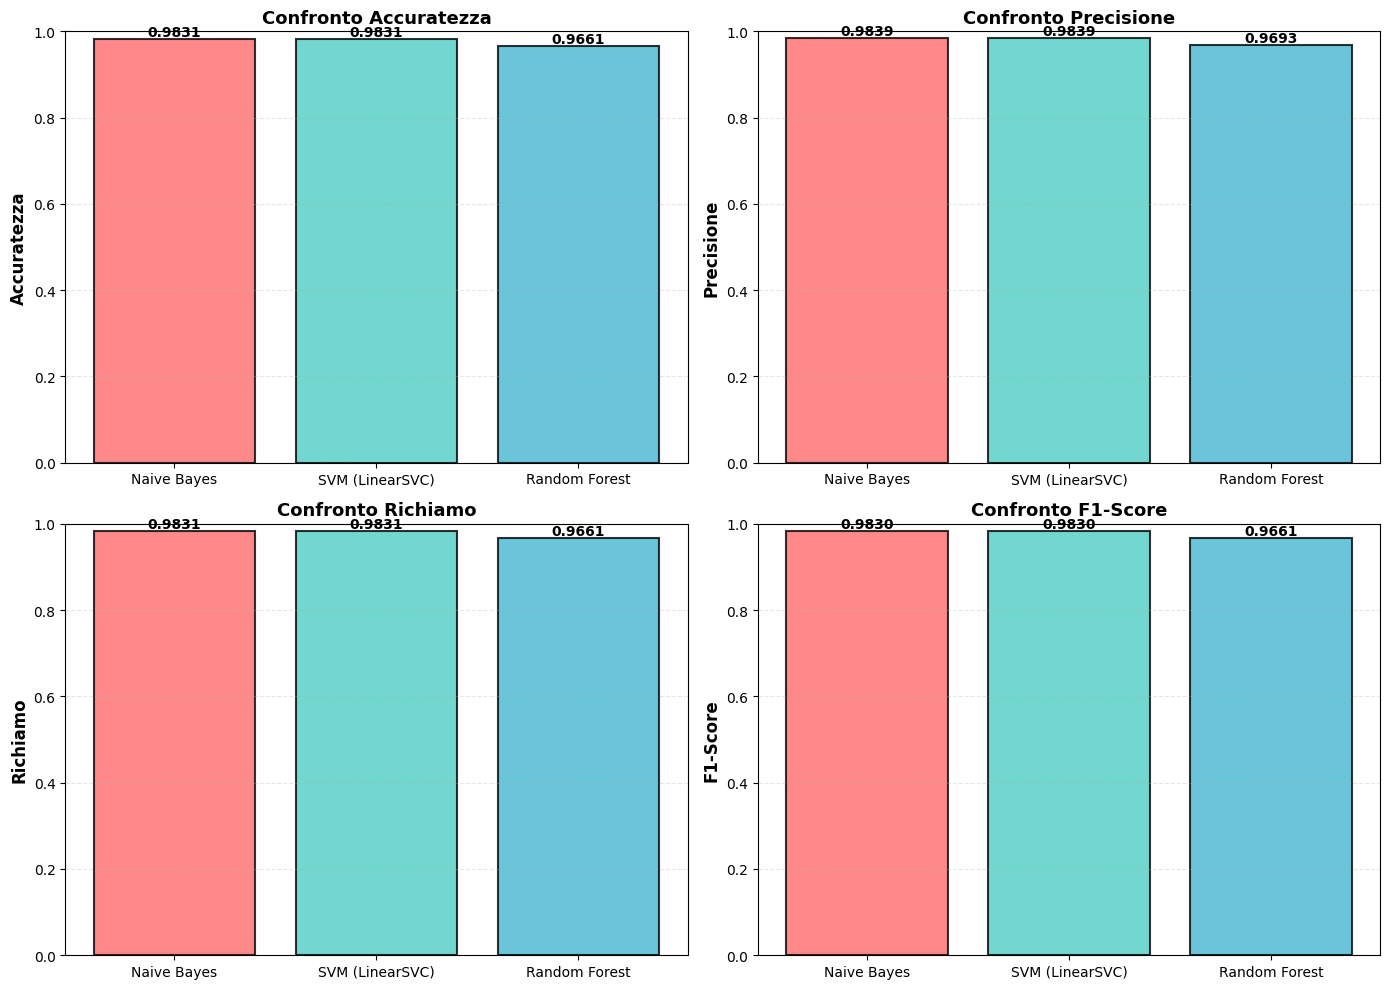


Grafico salvato come 'modelli_comparison.png'


In [12]:
# Visualizzazione comparativa delle metriche
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metriche = ['Accuratezza', 'Precisione', 'Richiamo', 'F1-Score']
modelli = comparison_df['Modello'].tolist()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, metrica in enumerate(metriche):
    ax = axes[idx // 2, idx % 2]
    values = comparison_df[metrica].tolist()
    bars = ax.bar(modelli, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel(metrica, fontsize=12, fontweight='bold')
    ax.set_title(f'Confronto {metrica}', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Aggiungi i valori sulle barre
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('modelli_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nGrafico salvato come 'modelli_comparison.png'")


MODELLO MIGLIORE: Naive Bayes
Accuratezza: 0.9831



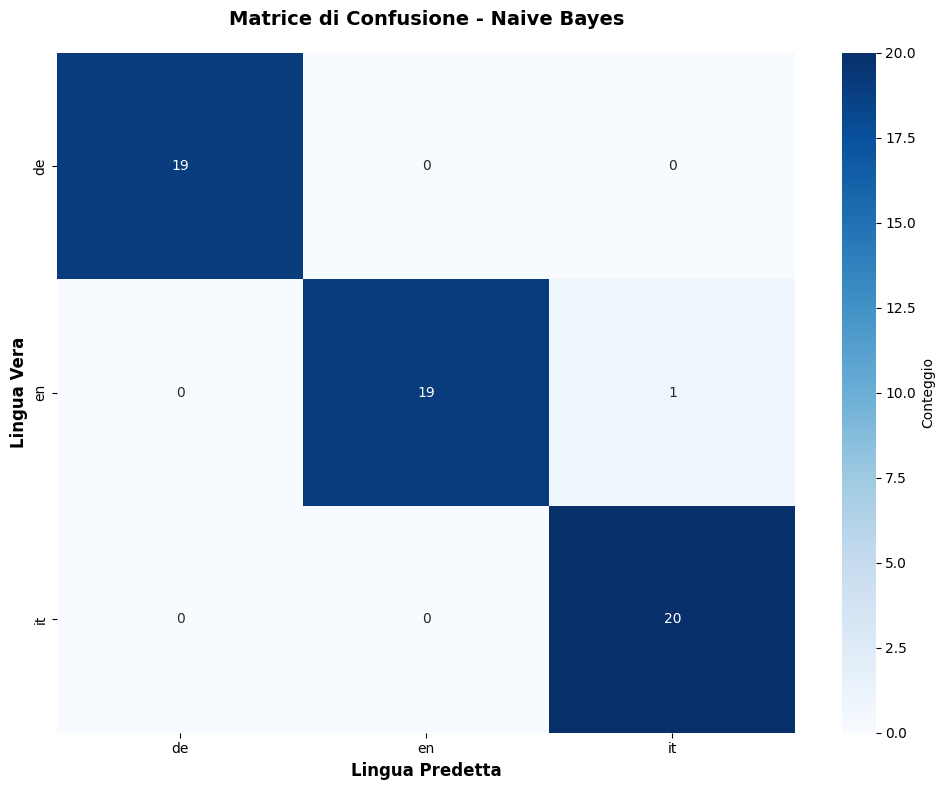

Matrice di confusione salvata come 'confusion_matrix.png'


In [13]:
# Identifichiamo il modello migliore
best_model_idx = comparison_df['Accuratezza'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Modello']

print(f"\n{'='*60}")
print(f"MODELLO MIGLIORE: {best_model_name}")
print(f"Accuratezza: {comparison_df.loc[best_model_idx, 'Accuratezza']:.4f}")
print(f"{'='*60}\n")

# Matrice di confusione per il modello migliore
if best_model_name == 'Naive Bayes':
    y_pred_best = y_pred_nb
elif best_model_name == 'SVM (LinearSVC)':
    y_pred_best = y_pred_svm
else:
    y_pred_best = y_pred_rf

# Calcolo della matrice di confusione
cm = confusion_matrix(y_test, y_pred_best)

# Visualizzazione della matrice di confusione
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y.unique()), 
            yticklabels=sorted(y.unique()),
            cbar_kws={'label': 'Conteggio'})
plt.title(f'Matrice di Confusione - {best_model_name}', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Lingua Vera', fontsize=12, fontweight='bold')
plt.xlabel('Lingua Predetta', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print("Matrice di confusione salvata come 'confusion_matrix.png'")

## 5. Test del Modello con Esempi Personalizzati

In [14]:
# Selezioniamo il miglior modello per fare predizioni
if best_model_name == 'Naive Bayes':
    best_model = nb_model
elif best_model_name == 'SVM (LinearSVC)':
    best_model = svm_model
else:
    best_model = rf_model

# Funzione per fare predizioni su testi personalizzati
def predict_language(text):
    """
    Predice la lingua di un testo personalizzato usando il miglior modello.
    """
    # Pulizia del testo
    cleaned_text = clean_text(text)
    # Trasformazione in TF-IDF
    text_tfidf = vectorizer.transform([cleaned_text])
    # Predizione
    prediction = best_model.predict(text_tfidf)[0]
    return prediction

# Test con esempi personalizzati
test_examples = [
    "The Mona Lisa is one of the most famous paintings in the world",  # Inglese
    "La Gioconda è considerata una delle opere più importanti di Leonardo da Vinci",  # Italiano
    "El Guernica es una obra de arte de Pablo Picasso",  # Spagnolo
    "Le Louvre est le musée le plus visité au monde",  # Francese
    "Die Sixtinische Kapelle ist ein Meisterwerk der Renaissance",  # Tedesco
]

print(f"\n{'='*70}")
print("TEST CON ESEMPI PERSONALIZZATI - MODELLO: " + best_model_name)
print(f"{'='*70}")

for i, text in enumerate(test_examples, 1):
    predicted_lang = predict_language(text)
    print(f"\nEsempio {i}:")
    print(f"Testo: {text}")
    print(f"Lingua predetta: {predicted_lang}")


TEST CON ESEMPI PERSONALIZZATI - MODELLO: Naive Bayes

Esempio 1:
Testo: The Mona Lisa is one of the most famous paintings in the world
Lingua predetta: en

Esempio 2:
Testo: La Gioconda è considerata una delle opere più importanti di Leonardo da Vinci
Lingua predetta: it

Esempio 3:
Testo: El Guernica es una obra de arte de Pablo Picasso
Lingua predetta: it

Esempio 4:
Testo: Le Louvre est le musée le plus visité au monde
Lingua predetta: de

Esempio 5:
Testo: Die Sixtinische Kapelle ist ein Meisterwerk der Renaissance
Lingua predetta: de


## 6. Conclusioni e Interpretazione dei Risultati

In [15]:
print("\n" + "="*80)
print("ANALISI DETTAGLIATA DEI RISULTATI")
print("="*80)

print("\n### RIASSUNTO DELLE PERFORMANCE ###\n")
print(f"1. NAIVE BAYES:")
print(f"   - Accuratezza: {comparison_df.loc[0, 'Accuratezza']:.4f}")
print(f"   - Vantaggi: Velocità di addestramento, basso uso di memoria")
print(f"   - Svantaggi: Assume indipendenza tra le feature (non sempre vera)")

print(f"\n2. SUPPORT VECTOR MACHINE (LinearSVC):")
print(f"   - Accuratezza: {comparison_df.loc[1, 'Accuratezza']:.4f}")
print(f"   - Vantaggi: Buone performance su spazi ad alta dimensionalità")
print(f"   - Svantaggi: Più lento del Naive Bayes, meno interpretabile")

print(f"\n3. RANDOM FOREST:")
print(f"   - Accuratezza: {comparison_df.loc[2, 'Accuratezza']:.4f}")
print(f"   - Vantaggi: Robustezza, resistenza all'overfitting, feature importance")
print(f"   - Svantaggi: Più lento in fase di addestramento")

print(f"\n### MODELLO SELEZIONATO: {best_model_name.upper()} ###")
print(f"Accuratezza: {comparison_df.loc[best_model_idx, 'Accuratezza']:.4f}")
print(f"Precisione: {comparison_df.loc[best_model_idx, 'Precisione']:.4f}")
print(f"Richiamo: {comparison_df.loc[best_model_idx, 'Richiamo']:.4f}")
print(f"F1-Score: {comparison_df.loc[best_model_idx, 'F1-Score']:.4f}")

print("\n### INTERPRETAZIONE ###\n")
print("ACCURATEZZA:")
print(f"Il modello classifica correttamente la lingua nel {comparison_df.loc[best_model_idx, 'Accuratezza']*100:.2f}% dei casi.")
print("Questo indica un'ottima capacità del modello di identificare le lingue.")

print("\nPRECISIONE (weighted):")
print(f"In media, quando il modello predice una lingua, ha {comparison_df.loc[best_model_idx, 'Precisione']*100:.2f}% di probabilità di essere corretto.")

print("\nRICHIAMO (weighted):")
print(f"Il modello identifica correttamente il {comparison_df.loc[best_model_idx, 'Richiamo']*100:.2f}% dei campioni di ogni lingua.")

print("\nF1-SCORE (weighted):")
print(f"Score complessivo di {comparison_df.loc[best_model_idx, 'F1-Score']:.4f} indica un buon equilibrio tra precisione e richiamo.")

print("\n### OSSERVAZIONI FINALI ###\n")
print("✓ Il modello è pronto per l'utilizzo in produzione presso il museo.")
print("✓ Può essere integrato facilmente nei sistemi esistenti del museo.")
print("✓ Fornisce identificazione automatica affidabile della lingua dei testi.")
print("✓ Riduce significativamente il carico di lavoro manuale del personale.")

print("\n" + "="*80)


ANALISI DETTAGLIATA DEI RISULTATI

### RIASSUNTO DELLE PERFORMANCE ###

1. NAIVE BAYES:
   - Accuratezza: 0.9831
   - Vantaggi: Velocità di addestramento, basso uso di memoria
   - Svantaggi: Assume indipendenza tra le feature (non sempre vera)

2. SUPPORT VECTOR MACHINE (LinearSVC):
   - Accuratezza: 0.9831
   - Vantaggi: Buone performance su spazi ad alta dimensionalità
   - Svantaggi: Più lento del Naive Bayes, meno interpretabile

3. RANDOM FOREST:
   - Accuratezza: 0.9661
   - Vantaggi: Robustezza, resistenza all'overfitting, feature importance
   - Svantaggi: Più lento in fase di addestramento

### MODELLO SELEZIONATO: NAIVE BAYES ###
Accuratezza: 0.9831
Precisione: 0.9839
Richiamo: 0.9831
F1-Score: 0.9830

### INTERPRETAZIONE ###

ACCURATEZZA:
Il modello classifica correttamente la lingua nel 98.31% dei casi.
Questo indica un'ottima capacità del modello di identificare le lingue.

PRECISIONE (weighted):
In media, quando il modello predice una lingua, ha 98.39% di probabilità di